In [1]:
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
import pandas as pd
import numpy  as np
import math, json, os

pd.set_option('display.max_columns', None)

# CONFIGURAÇÕES

In [2]:
OPTIONS = json.loads(open('../../../info.json', 'r', encoding='utf-8').read())
OPTIONS

{'dynamic_tests': 1, 'static_tests': 1}

In [3]:
TEST_NUM = OPTIONS['dynamic_tests']
PATH     = f'../files/test{TEST_NUM}'
PATH

'../files/test1'

In [4]:
TARGET_VAR  = 'pitch'
TARGET_TIME = json.loads(open(os.path.join(PATH, 'info.json'), 'r').read()).get('limits') 
TARGET_TIME

[15, 1000000000.0]

# IMPORTANDO DADOS

In [5]:
df = pd.read_csv(f'{PATH}/reference/data.csv')
df.loc[:, 'time'] = df.time - df.time.values[0]
df

,la_pos_mon_d,time,yaw,ax,wx,roll,q0,wz,az,pitch,wy,ay,q2,sample_time,q3,q1
0,-0.03839,0.000000,-0.4687,0.07028,0.000249,1.576,0.6856,-0.000099,0.05007,0.004841,-0.000337,-9.789,-0.1630,5000000.0,-0.1654,0.6899
1,-0.03844,0.048256,-0.4687,0.07061,0.000070,1.576,0.6856,0.000175,0.05016,0.004844,-0.000372,-9.788,-0.1630,105000000.0,-0.1655,0.6899
2,-0.03849,0.095500,-0.4688,0.07060,-0.000315,1.576,0.6856,-0.000014,0.05012,0.004844,-0.000506,-9.788,-0.1630,205000000.0,-0.1655,0.6899
3,-0.03854,0.206316,-0.4688,0.07040,0.000005,1.576,0.6856,-0.000061,0.05011,0.004844,-0.000450,-9.789,-0.1630,305000000.0,-0.1655,0.6899
4,-0.03859,0.298519,-0.4689,0.07067,0.000104,1.576,0.6856,0.000122,0.05000,0.004844,-0.000383,-9.788,-0.1630,405000000.0,-0.1655,0.6899
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3306,0.22300,330.534400,-0.5040,0.07978,-0.000060,1.576,0.6829,-0.000086,0.04214,0.001747,-0.000444,-9.788,-0.1761,605000000.0,-0.1765,0.6866
3307,0.22330,330.631263,-0.5040,0.07960,-0.000117,1.576,0.6829,0.000039,0.04216,0.001739,-0.000357,-9.789,-0.1762,705000000.0,-0.1765,0.6866
3308,0.22360,330.722081,-0.5041,0.07995,0.000003,1.576,0.6829,0.000034,0.04192,0.001739,-0.000424,-9.788,-0.1762,805000000.0,-0.1765,0.6866
3309,0.22390,330.829164,-0.5041,0.08003,0.000346,1.576,0.6829,0.000243,0.04169,0.001728,-0.000262,-9.788,-0.1762,905000000.0,-0.1765,0.6866


- Convertendo pra radianos

In [6]:
for col in ['wx', 'wy', 'wz', 'pitch', 'roll', 'yaw']:
    df.loc[:, col] = df[col] * 180.00/np.pi

df

,la_pos_mon_d,time,yaw,ax,wx,roll,q0,wz,az,pitch,wy,ay,q2,sample_time,q3,q1
0,-0.03839,0.000000,-26.854532,0.07028,0.014261,90.298149,0.6856,-0.005651,0.05007,0.277369,-0.019314,-9.789,-0.1630,5000000.0,-0.1654,0.6899
1,-0.03844,0.048256,-26.854532,0.07061,0.004013,90.298149,0.6856,0.009998,0.05016,0.277541,-0.021314,-9.788,-0.1630,105000000.0,-0.1655,0.6899
2,-0.03849,0.095500,-26.860261,0.07060,-0.018048,90.298149,0.6856,-0.000816,0.05012,0.277541,-0.028992,-9.788,-0.1630,205000000.0,-0.1655,0.6899
3,-0.03854,0.206316,-26.860261,0.07040,0.000293,90.298149,0.6856,-0.003522,0.05011,0.277541,-0.025789,-9.789,-0.1630,305000000.0,-0.1655,0.6899
4,-0.03859,0.298519,-26.865991,0.07067,0.005942,90.298149,0.6856,0.006996,0.05000,0.277541,-0.021956,-9.788,-0.1630,405000000.0,-0.1655,0.6899
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3306,0.22300,330.534400,-28.877073,0.07978,-0.003453,90.298149,0.6829,-0.004904,0.04214,0.100096,-0.025416,-9.788,-0.1761,605000000.0,-0.1765,0.6866
3307,0.22330,330.631263,-28.877073,0.07960,-0.006681,90.298149,0.6829,0.002209,0.04216,0.099637,-0.020432,-9.789,-0.1762,705000000.0,-0.1765,0.6866
3308,0.22360,330.722081,-28.882802,0.07995,0.000197,90.298149,0.6829,0.001937,0.04192,0.099637,-0.024270,-9.788,-0.1762,805000000.0,-0.1765,0.6866
3309,0.22390,330.829164,-28.882802,0.08003,0.019813,90.298149,0.6829,0.013940,0.04169,0.099007,-0.015040,-9.788,-0.1762,905000000.0,-0.1765,0.6866


# VISUALIZAÇÃO DE VARIÁVEIS

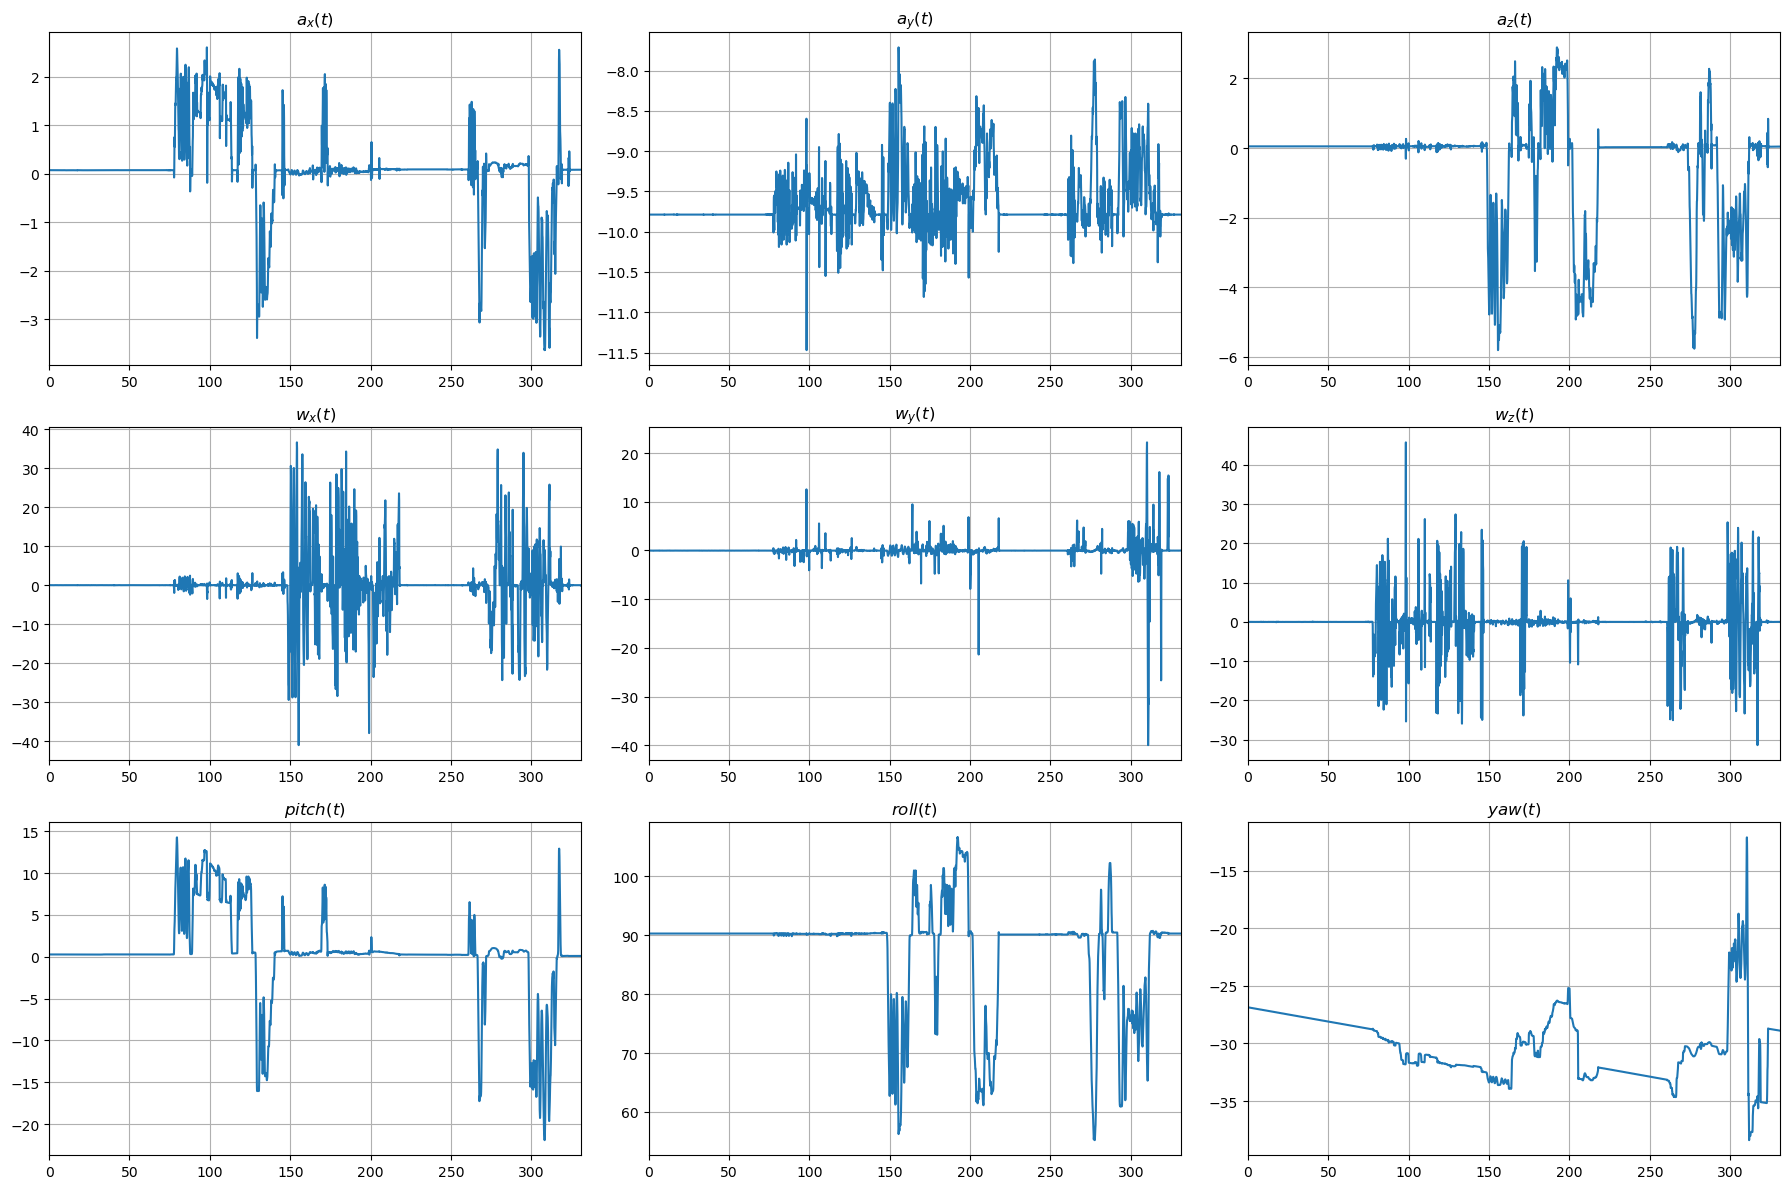

In [7]:
def compareAxis(time, data, limits=(0, 1), yLim=None):
    t_min, t_max = time.min(), time.max()
    delta = t_max - t_min
    
    start_time = t_min + (delta * limits[0])
    end_time   = t_min + (delta * limits[1])
    
    count   = len(data.keys())
    numCols = 3 if count >= 3 else count
    numRows = math.ceil(count / numCols)
    plt.figure(figsize=(6*numCols, 4*numRows))

    for i, (key, values) in enumerate(data.items()):
        mask = (time >= start_time) & (time <= end_time)
        target_time = time[mask]
        target_vals = values[mask]

        plt.subplot(numRows, numCols, i+1)
        plt.plot(target_time, target_vals)
        
        plt.xlim(start_time, end_time) 
        if yLim: plt.ylim(yLim)
        plt.title(key)
        plt.grid(True)

    plt.tight_layout()
    plt.show()

def plotAll(df, limits=(0, 1)):
    compareAxis(df.time, {
        '$a_x(t)$': df.ax, '$a_y(t)$': df.ay, '$a_z(t)$': df.az,
        '$w_x(t)$': df.wx, '$w_y(t)$': df.wy, '$w_z(t)$': df.wz,
        '$pitch(t)$': df.pitch, '$roll(t)$': df.roll, '$yaw(t)$': df.yaw
    }, limits)


plotAll(df, limits=(0, 1))

# AMOSTRAGEM

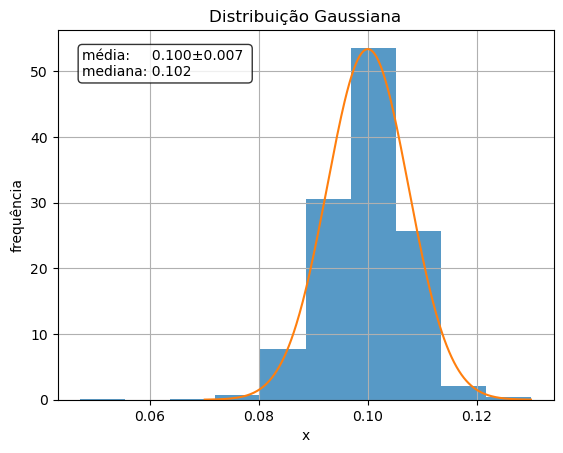

In [8]:
def gaussian(data):
    data  = np.array(data)
    n     = data.shape[0]
    mu    = data.mean()
    sigma = data.std()

    x  = np.linspace(mu - 4*sigma, mu + 4*sigma, 400)
    y  = (1/(sigma*np.sqrt(2*np.pi))) * np.exp(-0.5*((x - mu)/sigma)**2)
    plt.title(f'Distribuição Gaussiana')
    plt.hist(data, density=True, alpha=0.75)
    plt.plot(x, y)
    
    text = f'média:     {mu:.3f}±{sigma:.3f} \nmediana: {np.median(data):.3f}'
    opts = dict(boxstyle='round', facecolor='white', alpha=0.8)
    plt.text(0.05, 0.95, text, transform=plt.gca().transAxes, verticalalignment='top', bbox=opts)
    plt.xlabel('x'); plt.ylabel('frequência'); plt.grid()


time = df.time.diff()[1:].to_numpy()
dt   = np.median(time).round(2)
dt = 0.10
gaussian(time)

In [9]:
def normalizePeriod(df, key, dt=0.15):
    df = df.copy().sort_values(key)
    df[key] = df[key] - df[key].iloc[0]

    initTime  = df[key].iloc[0]
    finalTime = df[key].iloc[-1] + dt
    n = int(np.floor((finalTime - initTime) / dt)) + 1
    newAxis = np.round(np.linspace(initTime, initTime + dt*(n-1), n), 10)
    target  = pd.DataFrame({key: newAxis})
    out = pd.merge_asof(target, df, on=key, direction='backward')
    return out


df = normalizePeriod(df, 'time', dt)
df

,time,la_pos_mon_d,yaw,ax,wx,roll,q0,wz,az,pitch,wy,ay,q2,sample_time,q3,q1
0,0.0,-0.03839,-26.854532,0.07028,0.014261,90.298149,0.6856,-0.005651,0.05007,0.277369,-0.019314,-9.789,-0.1630,5000000.0,-0.1654,0.6899
1,0.1,-0.03849,-26.860261,0.07060,-0.018048,90.298149,0.6856,-0.000816,0.05012,0.277541,-0.028992,-9.788,-0.1630,205000000.0,-0.1655,0.6899
2,0.2,-0.03849,-26.860261,0.07060,-0.018048,90.298149,0.6856,-0.000816,0.05012,0.277541,-0.028992,-9.788,-0.1630,205000000.0,-0.1655,0.6899
3,0.3,-0.03859,-26.865991,0.07067,0.005942,90.298149,0.6856,0.006996,0.05000,0.277541,-0.021956,-9.788,-0.1630,405000000.0,-0.1655,0.6899
4,0.4,-0.03859,-26.865991,0.07067,0.005942,90.298149,0.6856,0.006996,0.05000,0.277541,-0.021956,-9.788,-0.1630,405000000.0,-0.1655,0.6899
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3306,330.6,0.22300,-28.877073,0.07978,-0.003453,90.298149,0.6829,-0.004904,0.04214,0.100096,-0.025416,-9.788,-0.1761,605000000.0,-0.1765,0.6866
3307,330.7,0.22330,-28.877073,0.07960,-0.006681,90.298149,0.6829,0.002209,0.04216,0.099637,-0.020432,-9.789,-0.1762,705000000.0,-0.1765,0.6866
3308,330.8,0.22360,-28.882802,0.07995,0.000197,90.298149,0.6829,0.001937,0.04192,0.099637,-0.024270,-9.788,-0.1762,805000000.0,-0.1765,0.6866
3309,330.9,0.22390,-28.882802,0.08003,0.019813,90.298149,0.6829,0.013940,0.04169,0.099007,-0.015040,-9.788,-0.1762,905000000.0,-0.1765,0.6866


# FILTRANDO POR VARIAVEL

In [10]:
df = df.loc[(df.time >= TARGET_TIME[0]) & (df.time <= TARGET_TIME[1])]
df.loc[:, 'time'] = df.time - df.time.values[0]

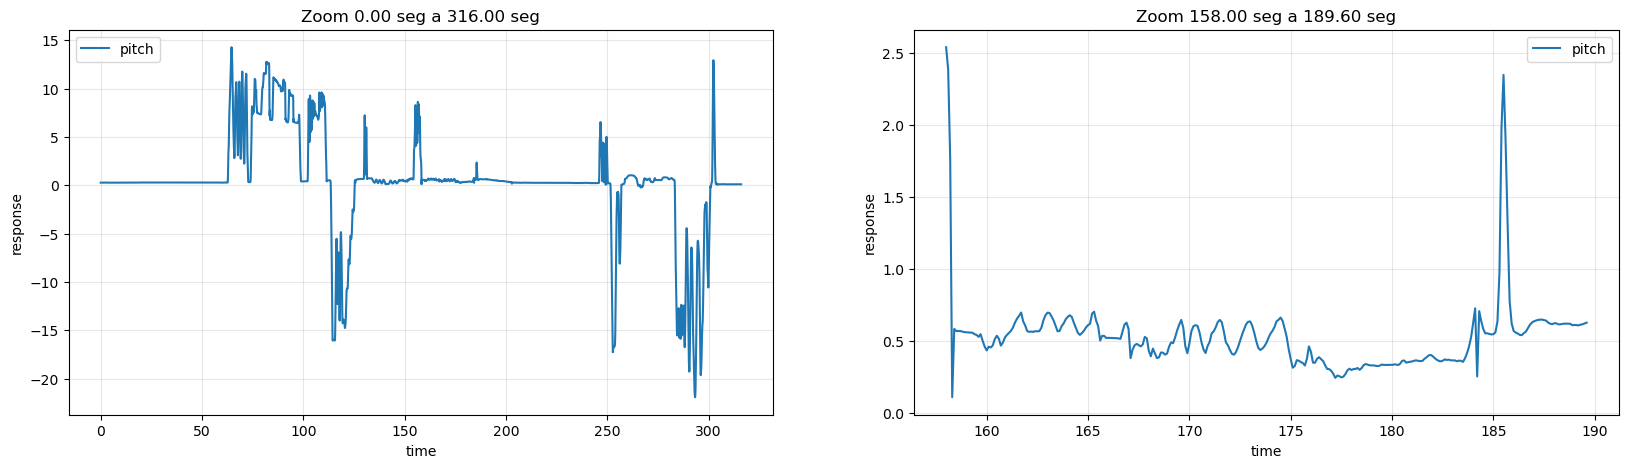

In [11]:
def plotViews(df, limits=(0, 1)):
    VIEW_TIME = (df.time.values[-1]*limits[0], df.time.values[-1]*limits[1])
    target    = df.loc[(df.time >= VIEW_TIME[0]) & (df.time <= VIEW_TIME[1])]

    plt.plot(target.time, target[TARGET_VAR], label=TARGET_VAR)
    plt.grid(alpha=.3); plt.legend(); plt.xlabel('time'); plt.ylabel('response')
    plt.title(f'Zoom {' a '.join([f'{val:.2f} seg' for val in df.time.max()*np.array(limits)])}')


plt.figure(figsize=(20, 5))
plt.subplot(1, 2, 1)
plotViews(df, limits=(0, 1))

plt.subplot(1, 2, 2)
plotViews(df, limits=(0.5, 0.6))

# SALVANDO DADOS

In [12]:
df = df.rename(columns={col: 'ref_' + col for col in df.columns if col != 'time'})
df

,time,ref_la_pos_mon_d,ref_yaw,ref_ax,ref_wx,ref_roll,ref_q0,ref_wz,ref_az,ref_pitch,ref_wy,ref_ay,ref_q2,ref_sample_time,ref_q3,ref_q1
150,0.0,-0.04529,-27.226954,0.06865,0.001649,90.298149,0.6851,-0.004888,0.05025,0.269462,-0.027548,-9.788,-0.1652,5000000.0,-0.1676,0.6894
151,0.1,-0.04534,-27.226954,0.06869,0.002540,90.298149,0.6851,-0.001643,0.05016,0.269290,-0.030676,-9.788,-0.1653,105000000.0,-0.1676,0.6894
152,0.2,-0.04538,-27.232684,0.06863,-0.006262,90.298149,0.6851,-0.001564,0.04992,0.269061,-0.029272,-9.788,-0.1653,205000000.0,-0.1676,0.6894
153,0.3,-0.04543,-27.232684,0.06853,-0.005907,90.298149,0.6851,0.003329,0.05004,0.269462,-0.022271,-9.789,-0.1653,305000000.0,-0.1677,0.6894
154,0.4,-0.04547,-27.238414,0.06897,0.001729,90.298149,0.6851,0.002807,0.05005,0.269691,-0.029593,-9.788,-0.1653,405000000.0,-0.1677,0.6894
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3306,315.6,0.22300,-28.877073,0.07978,-0.003453,90.298149,0.6829,-0.004904,0.04214,0.100096,-0.025416,-9.788,-0.1761,605000000.0,-0.1765,0.6866
3307,315.7,0.22330,-28.877073,0.07960,-0.006681,90.298149,0.6829,0.002209,0.04216,0.099637,-0.020432,-9.789,-0.1762,705000000.0,-0.1765,0.6866
3308,315.8,0.22360,-28.882802,0.07995,0.000197,90.298149,0.6829,0.001937,0.04192,0.099637,-0.024270,-9.788,-0.1762,805000000.0,-0.1765,0.6866
3309,315.9,0.22390,-28.882802,0.08003,0.019813,90.298149,0.6829,0.013940,0.04169,0.099007,-0.015040,-9.788,-0.1762,905000000.0,-0.1765,0.6866


In [13]:
os.makedirs('output', exist_ok=True)
df.to_csv('output/data.csv', index=None)